(sec:visualising_data)=
# Visualising Data with Matplotlib

Matplotlib is one of the main plotting libraries in Python.
It works especially well with NumPy, because NumPy arrays store numerical data in a form that is easy to plot.

## Learning goals
By the end of this notebook, you will be able to:
- plot simple line graphs,
- style lines and markers,
- generate x-grids with NumPy,
- add labels, titles, and axis limits,
- plot multiple datasets with a legend,
- use `fig, ax = plt.subplots()` for advanced control.


In [18]:
import numpy as np
import matplotlib.pyplot as plt

## 1) Simple line plot

`plt.plot()` is the basic plotting function in Matplotlib.

- If you pass one list, it is interpreted as y-values and Matplotlib uses x = `0, 1, 2, ...`.
- If you pass two lists, they are interpreted as corresponding x-values and y-values.

Use `plt.show()` to render the figure in the notebook output.


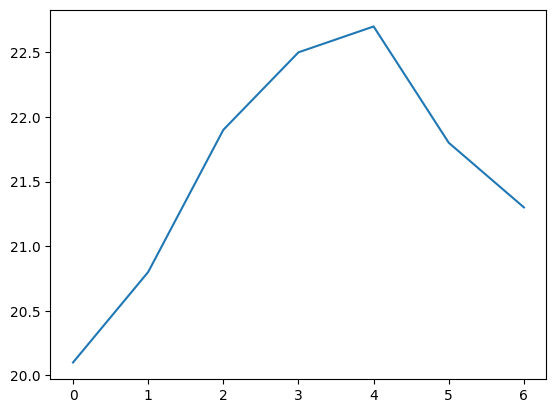

In [19]:
temperatures = [20.1, 20.8, 21.9, 22.5, 22.7, 21.8, 21.3]
plt.plot(temperatures)
plt.show()

You can also provide your own x-values explicitly.


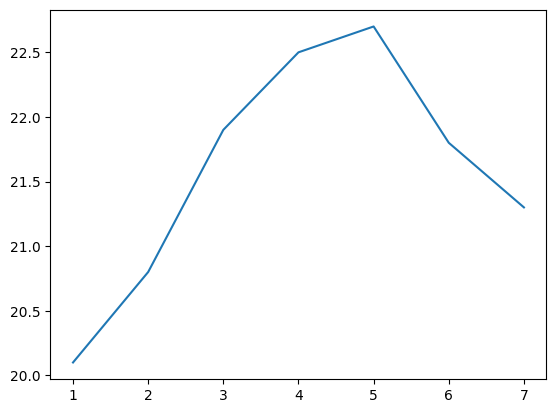

In [20]:
days = [1, 2, 3, 4, 5, 6, 7]
plt.plot(days, temperatures)
plt.show()

## 2) Plot styles

Matplotlib style can be set with format strings or keyword arguments.
This lets you make plots easier to read and compare.

Examples of markers and lines:
- line: `"-"`
- dots: `"o"`
- line + dots: `"-o"`
- triangles: `"^"`


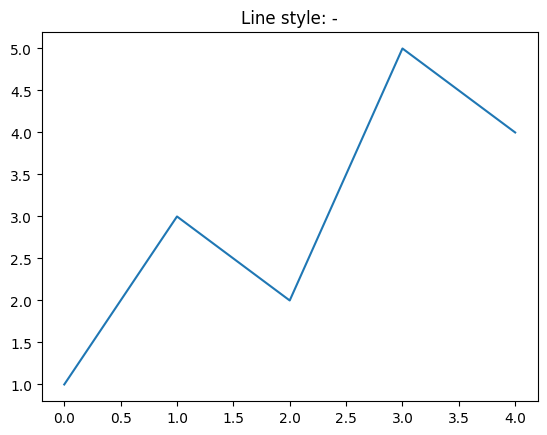

In [21]:
y = [1, 3, 2, 5, 4]
plt.plot(y, "-")
plt.title("Line style: -")
plt.show()

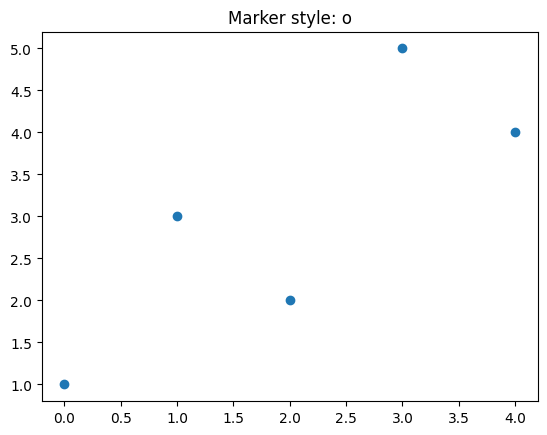

In [22]:
plt.plot(y, "o")
plt.title("Marker style: o")
plt.show()

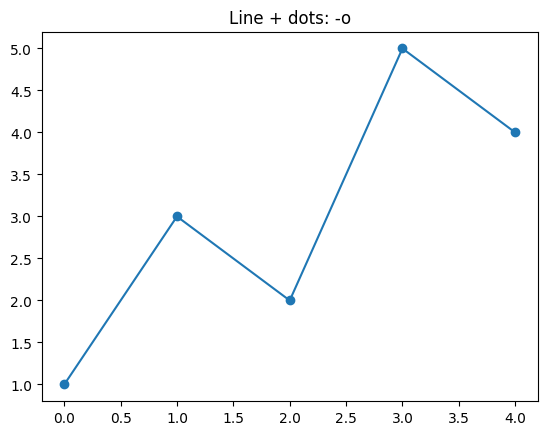

In [23]:
plt.plot(y, "-o", color="tab:blue")
plt.title("Line + dots: -o")
plt.show()

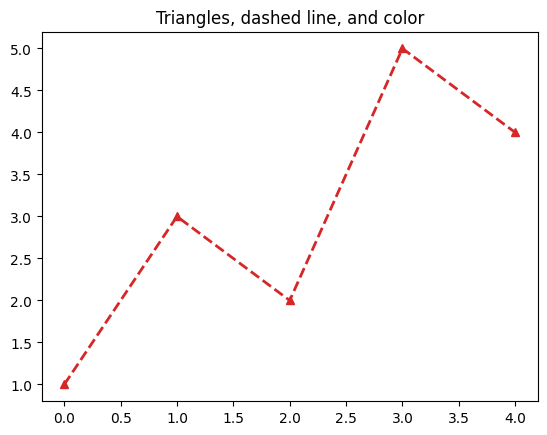

In [24]:
plt.plot(y, marker="^", linestyle="--", color="tab:red", linewidth=2)
plt.title("Triangles, dashed line, and color")
plt.show()

## 3) Grids and functions

A function like `sin(x)` is continuous, but a computer can only evaluate it at specific x-values.
So we first build a grid (a list/array of x-points), evaluate the function on that grid, and then plot those sampled points. Grids can be created with `np.arange()` or `np.linspace()`, which you learned about in the previous chapter.

In [36]:
x_arange = np.arange(0.0, 2 * np.pi, 0.2)
x_linspace = np.linspace(0.0, 2 * np.pi, 100)

print("arange first 6:", x_arange[:6])
print("linspace first 6:", x_linspace[:6])
print("linspace size:", x_linspace.size)

arange first 6: [0.  0.2 0.4 0.6 0.8 1. ]
linspace first 6: [0.         0.06346652 0.12693304 0.19039955 0.25386607 0.31733259]
linspace size: 100


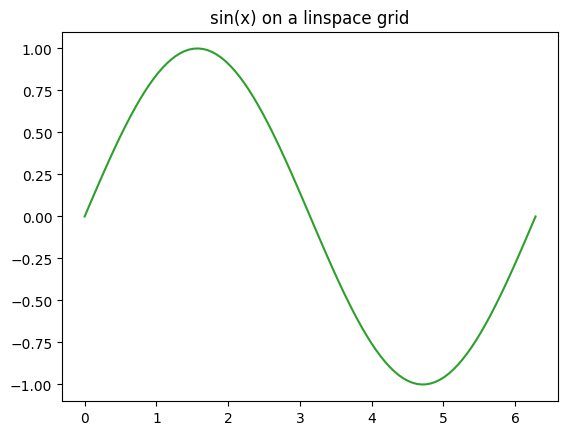

In [37]:
y_sin = np.sin(x_linspace)
plt.plot(x_linspace, y_sin, color="tab:green")
plt.title("sin(x) on a linspace grid")
plt.show()

## 4) Axis labels, title, and limits

Good plots should explain what is shown, so use `xlabel`, `ylabel`, and `title`.
You can use `xlim` and `ylim` to control the visible range.


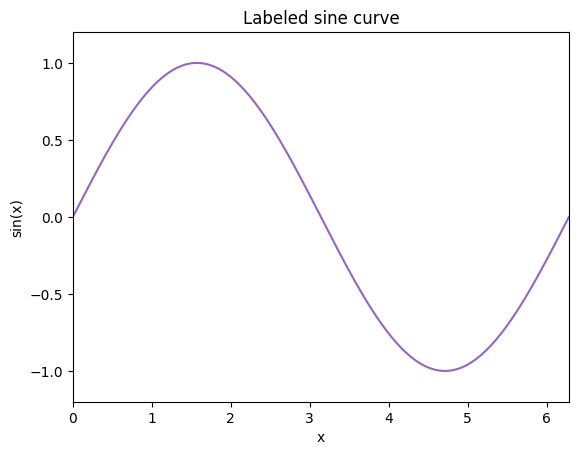

In [27]:
x = np.linspace(0.0, 2 * np.pi, 200)
y = np.sin(x)

plt.plot(x, y, color="tab:purple")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title("Labeled sine curve")
plt.xlim(0, 2 * np.pi)
plt.ylim(-1.2, 1.2)
plt.show()

## 5) Multiple lines and legend

To plot multiple datasets in one figure, you usually call `plt.plot(...)` repeatedly.
Each call adds another line to the same axes (until `plt.show()`).

Always add `label=...` so a legend can identify each line.
Use different colours and linestyles to improve readability.


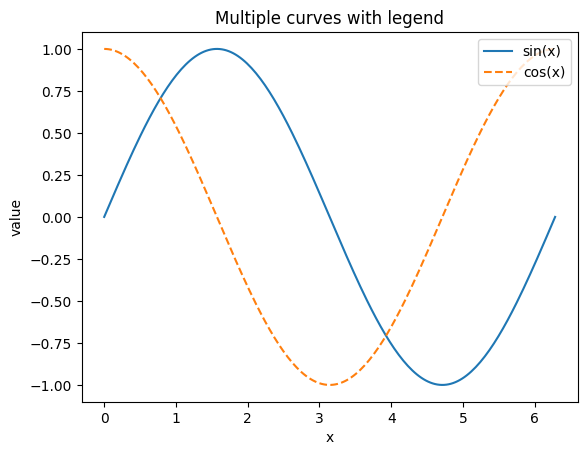

In [28]:
x = np.linspace(0.0, 2 * np.pi, 200)
y_sin = np.sin(x)
y_cos = np.cos(x)

plt.plot(x, y_sin, label="sin(x)", color="tab:blue", linestyle="-")
plt.plot(x, y_cos, label="cos(x)", color="tab:orange", linestyle="--")
plt.xlabel("x")
plt.ylabel("value")
plt.title("Multiple curves with legend")
plt.legend(loc="upper right")
plt.show()

## 6) Advanced control with `fig, ax`

An alternative to just calling `plt.plot(...)` is to use `fig, ax = plt.subplots()`.

`fig` is the full figure (the whole canvas).
`ax` is one axes object (the actual plotting area).

With `ax`, you get many methods for precise customization, for example:
- `ax.set_title(...)`, `ax.set_xlabel(...)`, `ax.set_ylabel(...)`
- `ax.set_xlim(...)`, `ax.set_ylim(...)`
- `ax.set_xticks(...)`, `ax.set_xticklabels(...)`
- spine control via `ax.spines[...]`

So for advanced formatting and multi-panel figures, `fig, ax` is the preferred approach.


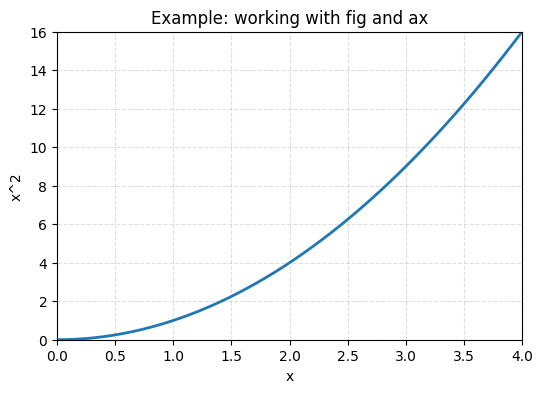

In [29]:
x = np.linspace(0, 4, 50)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, x**2, color="tab:blue", linewidth=2)
ax.set_title("Example: working with fig and ax")
ax.set_xlabel("x")
ax.set_ylabel("x^2")
ax.set_xlim(0, 4)
ax.set_ylim(0, 16)
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()

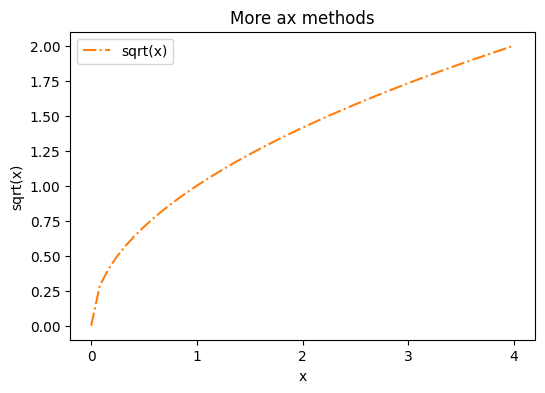

In [30]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, np.sqrt(x), color="tab:orange", linestyle="-.", label="sqrt(x)")

# A few additional ax methods
ax.set_title("More ax methods")
ax.set_xlabel("x")
ax.set_ylabel("sqrt(x)")
ax.set_xticks([0, 1, 2, 3, 4])
ax.legend(loc="upper left")

plt.show()

## 7) Example of axis customization

You can customize axis appearance directly through `ax`.
In this example we:
- hide top and right spines,
- move left and bottom spines to zero,
- set custom ticks and tick labels.


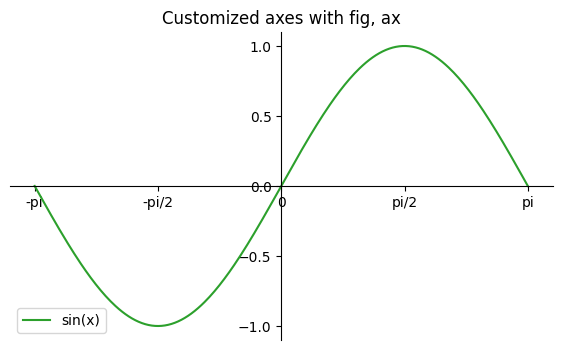

In [33]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.linspace(-np.pi, np.pi, 300)
y = np.sin(x)
ax.plot(x, y, color="tab:green", label="sin(x)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_position(("data", 0))
ax.spines["bottom"].set_position(("data", 0))

ticks = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
tick_labels = ["-pi", "-pi/2", "0", "pi/2", "pi"]
ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels)
ax.set_yticks([-1, -0.5, 0, 0.5, 1])

ax.set_title("Customized axes with fig, ax")
ax.legend(loc="lower left")
plt.show()

## 8) Generating multiple plots with `plt.subplots()`

With `plt.subplots(2, 2)`, you get a figure with four plots in a 2x2 grid. Here, `ax` is essentially a 2D array of axes objects.
This is ideal when you want to compare several plots side-by-side.

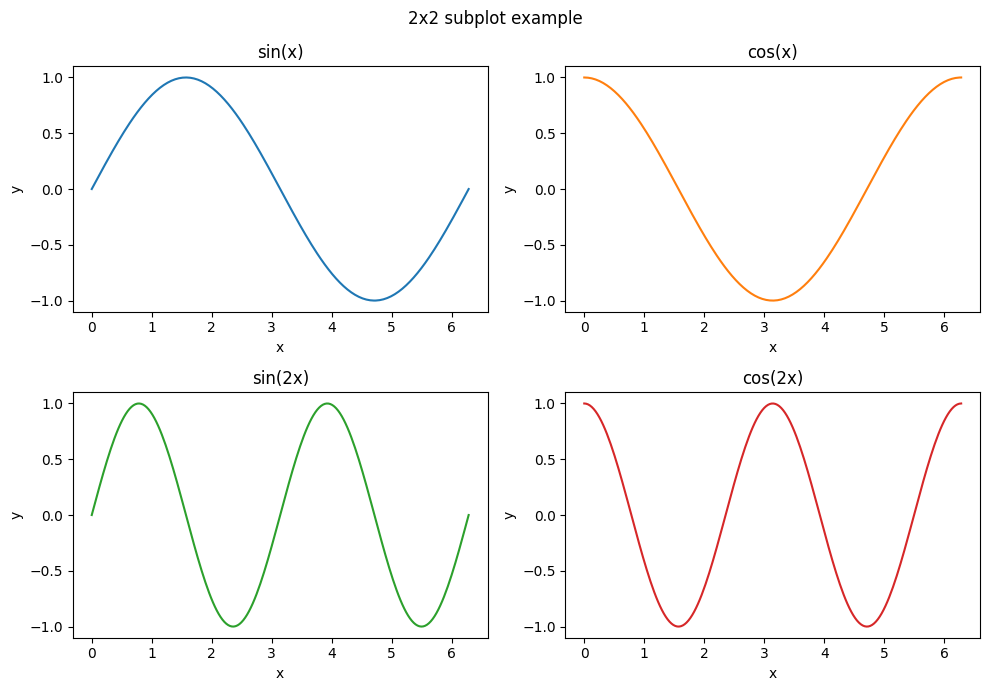

In [35]:
fig, axs = plt.subplots(2, 2, figsize=(10, 7)) # figsize in inches
ax1 = axs[0, 0]
ax2 = axs[0, 1]
ax3 = axs[1, 0]
ax4 = axs[1, 1]

x = np.linspace(0, 2 * np.pi, 200)
ax1.plot(x, np.sin(x), color="tab:blue")
ax1.set_title("sin(x)")

ax2.plot(x, np.cos(x), color="tab:orange")
ax2.set_title("cos(x)")

ax3.plot(x, np.sin(2 * x), color="tab:green")
ax3.set_title("sin(2x)")

ax4.plot(x, np.cos(2 * x), color="tab:red")
ax4.set_title("cos(2x)")

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.suptitle("2x2 subplot example")
fig.tight_layout()
plt.show()

## 9) Recap

You learned how to:
- create line plots from lists and arrays,
- control markers, lines, and colours,
- use `arange` and `linspace` grids for function plots,
- add labels, titles, limits, and legends,
- use `fig, ax` for advanced axis control and subplot layouts.


## 10) Mini practice

Try these tasks:
1. Plot a simple list of five values with markers only.
2. Create an `x` grid with `np.arange(0, 5, 0.5)` and plot `np.sin(x)`.
3. Add `xlabel`, `ylabel`, `title`, `xlim`, and `ylim` to one plot.
4. Plot `sin(x)` and `cos(x)` in one figure with different styles and a legend.
5. Build a 2x2 subplot figure and place one function in each panel.
